# Learning Rate Experiments for Vanilla DQN

This notebook runs a learning-rate ablation study for the vanilla DQN LunarLander baseline. All baseline parameters are kept fixed except `learning_rate`.


## 1. Setup and Imports


In [1]:
import sys
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))

from core.vanilla_dqn_lunar_lander import (
    train_dqn,
    evaluate_dqn,
    save_plot,
    save_results,
    save_model,
)


Using device: cpu


## 2. Experiment Settings

Keep the vanilla baseline settings unchanged and vary only the learning rate.


In [2]:
learning_rates = [3e-3, 2e-3, 1e-3, 8e-4, 7e-4, 5e-4, 3e-4, 1e-4, 5e-5]
num_episodes = 500
num_eval_episodes = 10

base_hyperparameters = {
    'batch_size': 32,
    'update_frequency': 4,
    'target_update_frequency': 100,
    'num_layers': 2,
    'hidden_dim': 128,
    'epsilon_decay': 0.995,
    'gamma': 0.99,
    'num_episodes': num_episodes,
    'num_eval_episodes': num_eval_episodes,
}


## 3. Run Learning Rate Ablation

Each learning rate is trained, evaluated, and saved automatically under `results/ablations/learning_rate/<learning_rate>/`.


In [3]:
all_results = {}

print('=' * 70)
print('DQN Learning Rate Ablation Study')
print(f'Testing {len(learning_rates)} learning rates over {num_episodes} episodes each')
print('=' * 70)

for lr in learning_rates:
    variant_name = f'{lr:.0e}'

    print('' + '=' * 70)
    print(f'Training with learning_rate = {lr} ({variant_name})')
    print('=' * 70)

    agent, rewards, losses = train_dqn(
        num_episodes=num_episodes,
        batch_size=base_hyperparameters['batch_size'],
        update_frequency=base_hyperparameters['update_frequency'],
        target_update_frequency=base_hyperparameters['target_update_frequency'],
        num_layers=base_hyperparameters['num_layers'],
        hidden_dim=base_hyperparameters['hidden_dim'],
        epsilon_decay=base_hyperparameters['epsilon_decay'],
        learning_rate=lr,
    )

    print('Evaluating trained agent...')
    eval_rewards = evaluate_dqn(agent, num_episodes=num_eval_episodes)

    hyperparameters = dict(base_hyperparameters)
    hyperparameters['learning_rate'] = lr

    save_results(
        agent,
        rewards,
        losses,
        hyperparameters,
        experiment_name='learning_rate',
        variant_name=variant_name,
    )
    save_model(agent, experiment_name='learning_rate', variant_name=variant_name)
    save_plot(rewards, losses, experiment_name='learning_rate', variant_name=variant_name)

    final_avg_reward = float(np.mean(rewards[-25:]))
    eval_avg_reward = float(np.mean(eval_rewards))

    all_results[variant_name] = {
        'learning_rate': lr,
        'train_rewards': rewards,
        'losses': losses,
        'eval_rewards': eval_rewards,
        'final_avg_reward': final_avg_reward,
        'eval_avg_reward': eval_avg_reward,
        'best_reward': float(max(rewards)),
    }

    print(f'Finished {variant_name}: final train avg={final_avg_reward:.2f}, eval avg={eval_avg_reward:.2f}')

print('' + '=' * 70)
print('Learning rate ablation complete')
print('=' * 70)


DQN Learning Rate Ablation Study
Testing 9 learning rates over 500 episodes each
Training with learning_rate = 0.003 (3e-03)
State dimension: 8
Action dimension: 4
Episode 50/500 | Avg Reward (last 50): -151.72 | Epsilon: 0.778
Episode 100/500 | Avg Reward (last 50): -172.95 | Epsilon: 0.606
Episode 150/500 | Avg Reward (last 50): -136.36 | Epsilon: 0.471
Episode 200/500 | Avg Reward (last 50): -146.36 | Epsilon: 0.367
Episode 250/500 | Avg Reward (last 50): -126.29 | Epsilon: 0.286
Episode 300/500 | Avg Reward (last 50): -152.51 | Epsilon: 0.222
Episode 350/500 | Avg Reward (last 50): -68.91 | Epsilon: 0.173
Episode 400/500 | Avg Reward (last 50): -83.15 | Epsilon: 0.135
Episode 450/500 | Avg Reward (last 50): -53.04 | Epsilon: 0.105
Episode 500/500 | Avg Reward (last 50): -87.31 | Epsilon: 0.082
Evaluating trained agent...
Evaluation Episode 1: Reward = -421.87
Evaluation Episode 2: Reward = -507.99
Evaluation Episode 3: Reward = -357.92
Evaluation Episode 4: Reward = -280.13
Evaluat

## 4. Compare Results


In [4]:
summary_rows = []

for variant_name, result in all_results.items():
    summary_rows.append({
        'variant': variant_name,
        'learning_rate': result['learning_rate'],
        'final_avg_reward_last_25': result['final_avg_reward'],
        'eval_avg_reward': result['eval_avg_reward'],
        'best_training_reward': result['best_reward'],
    })

summary_rows = sorted(summary_rows, key=lambda row: row['eval_avg_reward'], reverse=True)

print('Learning Rate Experiment Summary')
print('-' * 90)
print(f"{'Variant':<10} {'LR':<12} {'Final Avg (25)':<16} {'Eval Avg':<12} {'Best Train':<12}")
print('-' * 90)
for row in summary_rows:
    print(
        f"{row['variant']:<10} "
        f"{row['learning_rate']:<12.1e} "
        f"{row['final_avg_reward_last_25']:<16.2f} "
        f"{row['eval_avg_reward']:<12.2f} "
        f"{row['best_training_reward']:<12.2f}"
    )


Learning Rate Experiment Summary
------------------------------------------------------------------------------------------
Variant    LR           Final Avg (25)   Eval Avg     Best Train  
------------------------------------------------------------------------------------------
1e-03      1.0e-03      -34.68           48.13        288.47      
5e-04      5.0e-04      8.65             13.22        300.58      
1e-04      1.0e-04      1.44             7.50         290.04      
3e-04      3.0e-04      -21.92           0.27         264.81      
7e-04      7.0e-04      -7.79            -33.94       276.76      
5e-05      5.0e-05      -76.33           -82.08       247.90      
8e-04      8.0e-04      -36.77           -107.72      275.68      
3e-03      3.0e-03      -170.79          -376.68      266.91      
2e-03      2.0e-03      -49.87           -551.88      301.00      


## 5. Plot Comparison


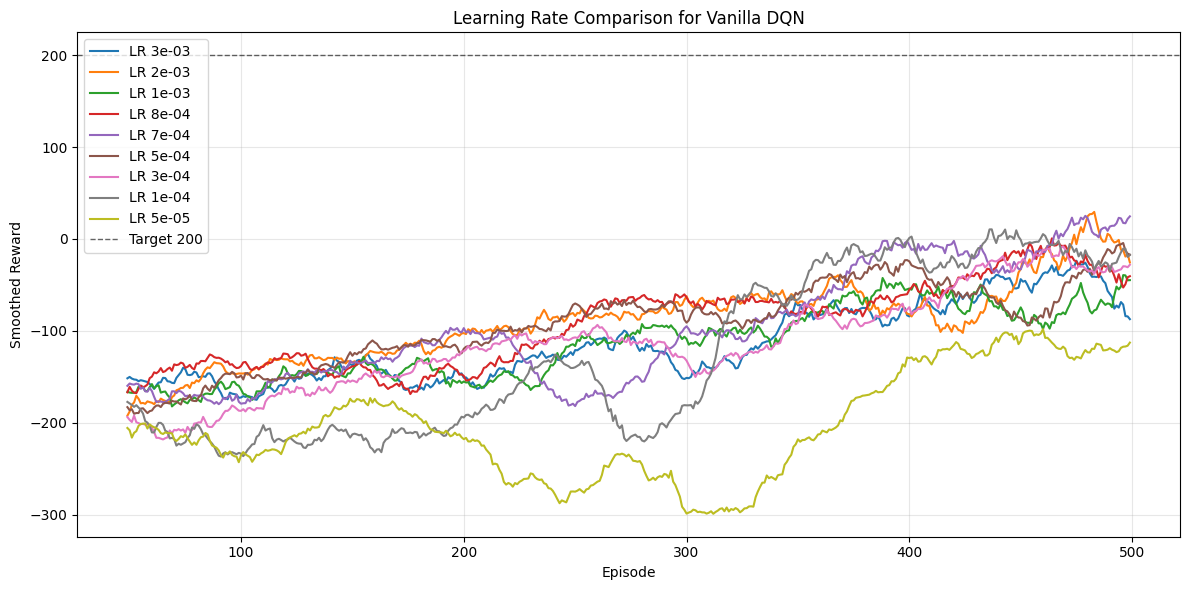

In [5]:
plt.figure(figsize=(12, 6))

for variant_name, result in all_results.items():
    rewards = result['train_rewards']
    window = min(50, max(1, len(rewards) // 2))
    if window > 1:
        smoothed = np.convolve(rewards, np.ones(window) / window, mode='valid')
        x_values = range(window - 1, window - 1 + len(smoothed))
        plt.plot(x_values, smoothed, label=f'LR {variant_name}')
    else:
        plt.plot(rewards, label=f'LR {variant_name}')

plt.axhline(y=200, color='black', linestyle='--', linewidth=1, alpha=0.6, label='Target 200')
plt.xlabel('Episode')
plt.ylabel('Smoothed Reward')
plt.title('Learning Rate Comparison for Vanilla DQN')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 5.1 Visualization: Individual Learning Rate Training Curves

Each subplot shows the raw episode reward and a smoothed reward curve for one learning rate. This makes it easier to inspect whether a setting shows consistent improvement, late recovery, or noisy isolated successes.



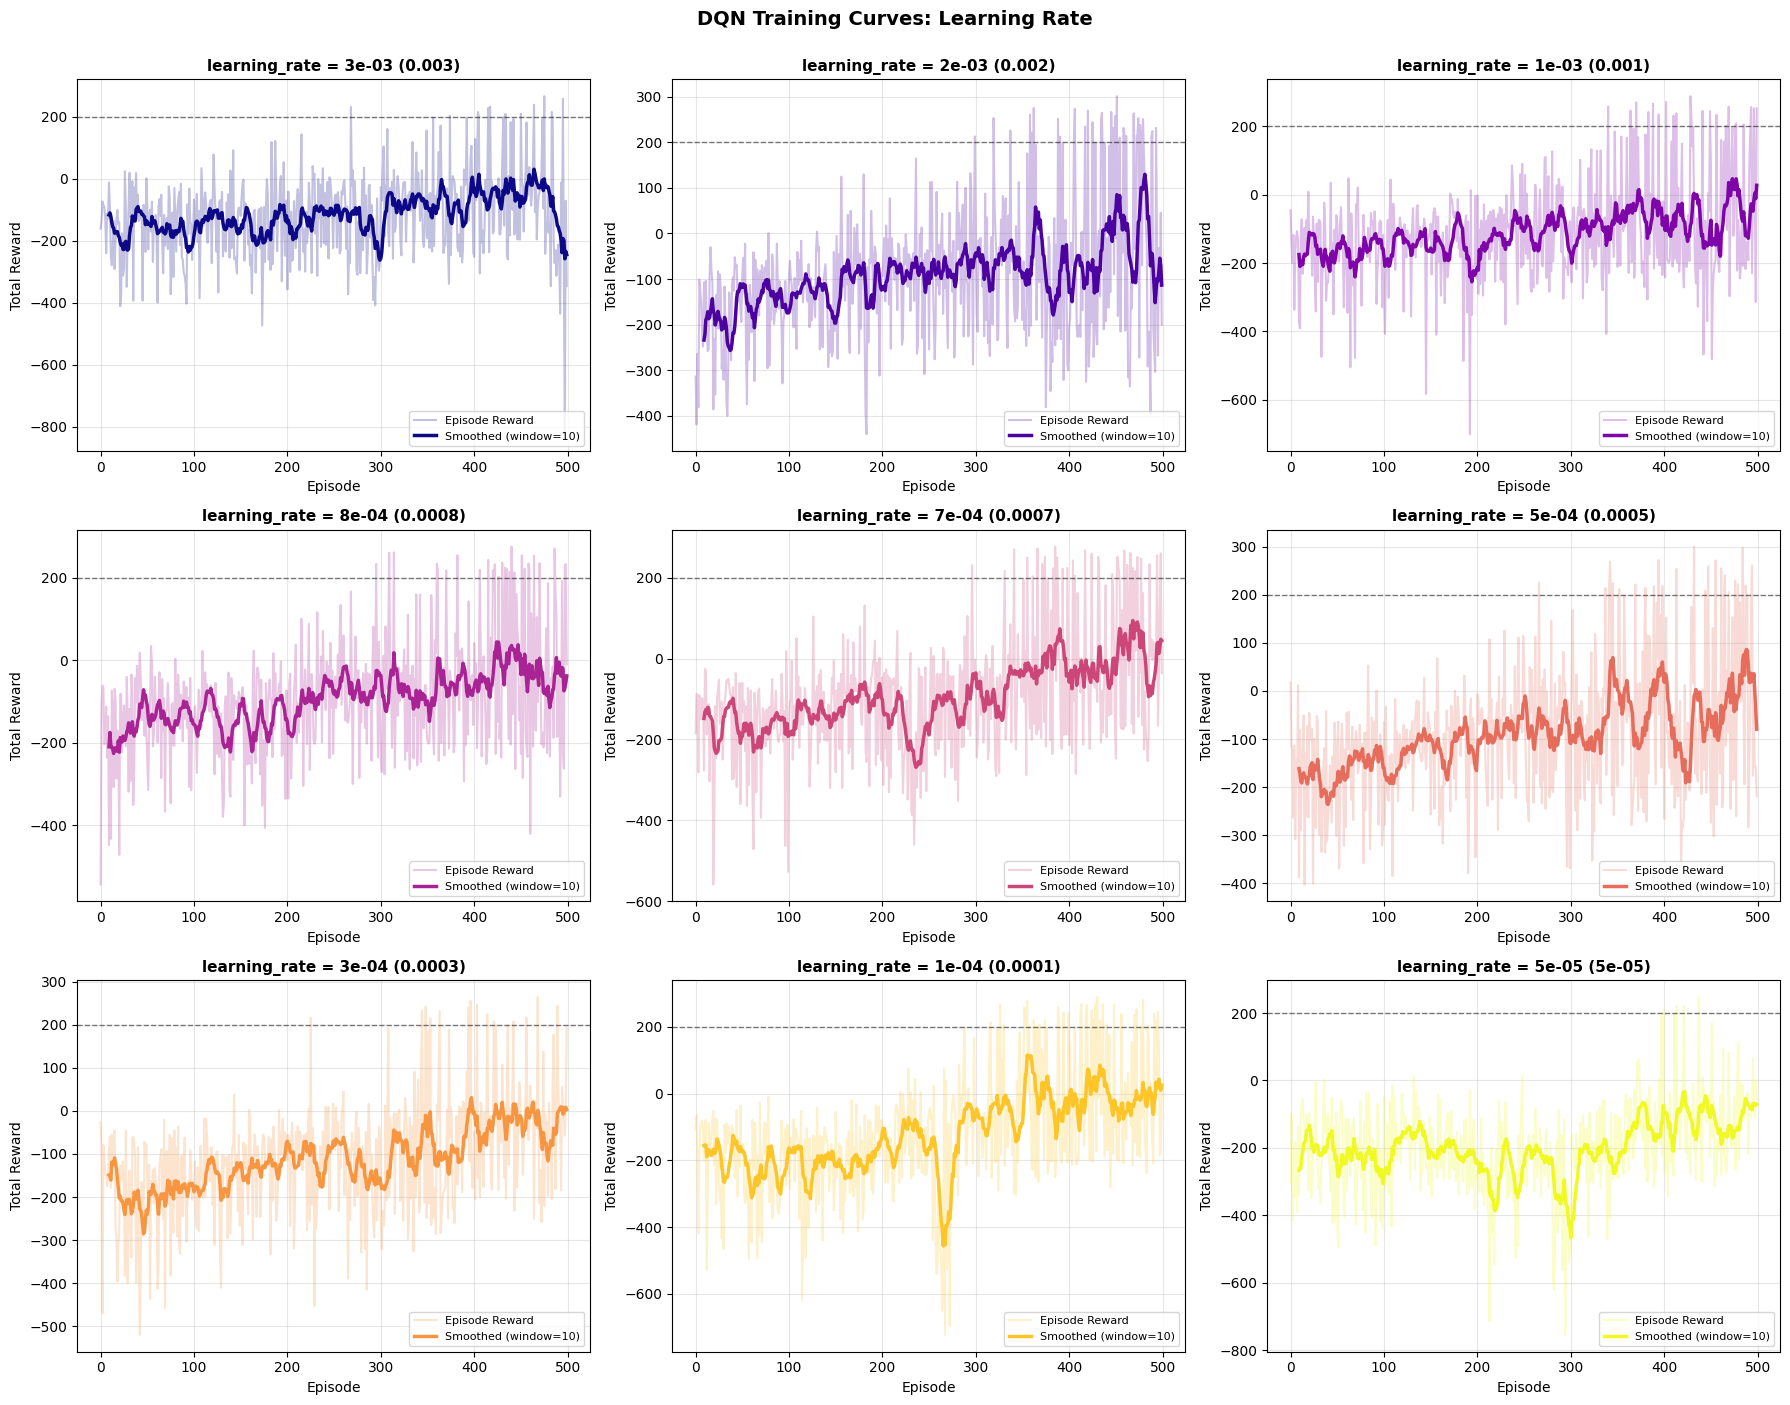

In [6]:
def format_lr_label(lr):
    return f'{lr:.0e} ({lr:g})'

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
colors = plt.cm.plasma(np.linspace(0, 1, len(summary_rows)))

# Plot from largest to smallest learning rate for easier visual comparison.
plot_rows = sorted(summary_rows, key=lambda row: row['learning_rate'], reverse=True)

for idx, row in enumerate(plot_rows):
    ax = axes[idx]
    variant_name = row['variant']
    result = all_results[variant_name]
    rewards = result['train_rewards']
    lr = result['learning_rate']
    color = colors[idx]
    window = 10

    ax.plot(rewards, alpha=0.25, color=color, label='Episode Reward')
    if len(rewards) >= window:
        smoothed = np.convolve(rewards, np.ones(window) / window, mode='valid')
        episodes = range(window - 1, window - 1 + len(smoothed))
        ax.plot(episodes, smoothed, linewidth=2.5, color=color, label=f'Smoothed (window={window})')

    ax.axhline(y=200, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_title(f'learning_rate = {format_lr_label(lr)}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='lower right')

plt.suptitle('DQN Training Curves: Learning Rate', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()



## 5.2 Visualization: Final, Evaluation, and Peak Performance

This comparison separates late-stage training reward, post-training evaluation reward, and the best single training episode. The separation matters because a high peak reward can be caused by one lucky trajectory and does not necessarily indicate a reliable learned policy.



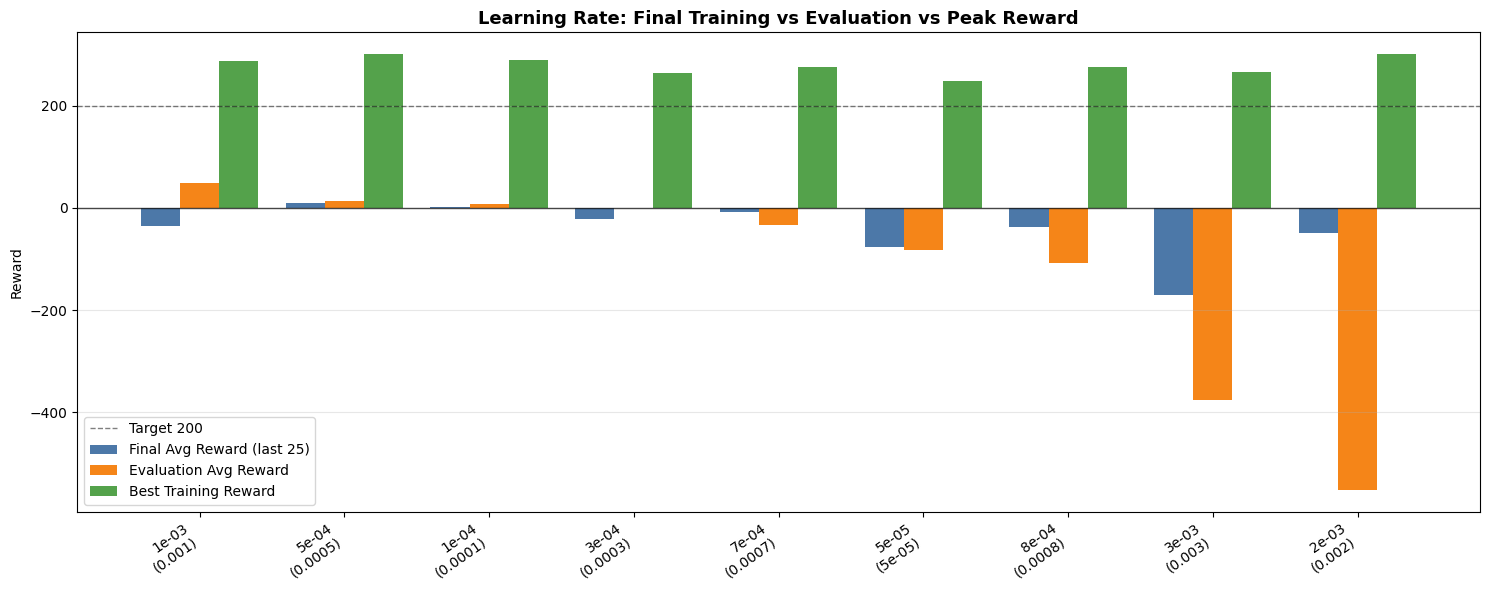

In [7]:
ordered_rows = sorted(summary_rows, key=lambda row: row['eval_avg_reward'], reverse=True)
labels = [f"{row['variant']}\n({row['learning_rate']:g})" for row in ordered_rows]
final_avgs = [row['final_avg_reward_last_25'] for row in ordered_rows]
eval_avgs = [row['eval_avg_reward'] for row in ordered_rows]
best_rewards = [row['best_training_reward'] for row in ordered_rows]

x = np.arange(len(ordered_rows))
width = 0.27

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(x - width, final_avgs, width, label='Final Avg Reward (last 25)', color='#4C78A8')
ax.bar(x, eval_avgs, width, label='Evaluation Avg Reward', color='#F58518')
ax.bar(x + width, best_rewards, width, label='Best Training Reward', color='#54A24B')
ax.axhline(y=0, color='black', linewidth=1, alpha=0.7)
ax.axhline(y=200, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Target 200')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha='right')
ax.set_ylabel('Reward')
ax.set_title('Learning Rate: Final Training vs Evaluation vs Peak Reward', fontsize=13, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()



## 5.3 Visualization: Rewards and Loss Comparison

The following plots compare representative learning rates across both reward and loss. They highlight whether reward improvement is accompanied by stable value-function updates, or whether the policy only achieves isolated reward spikes.



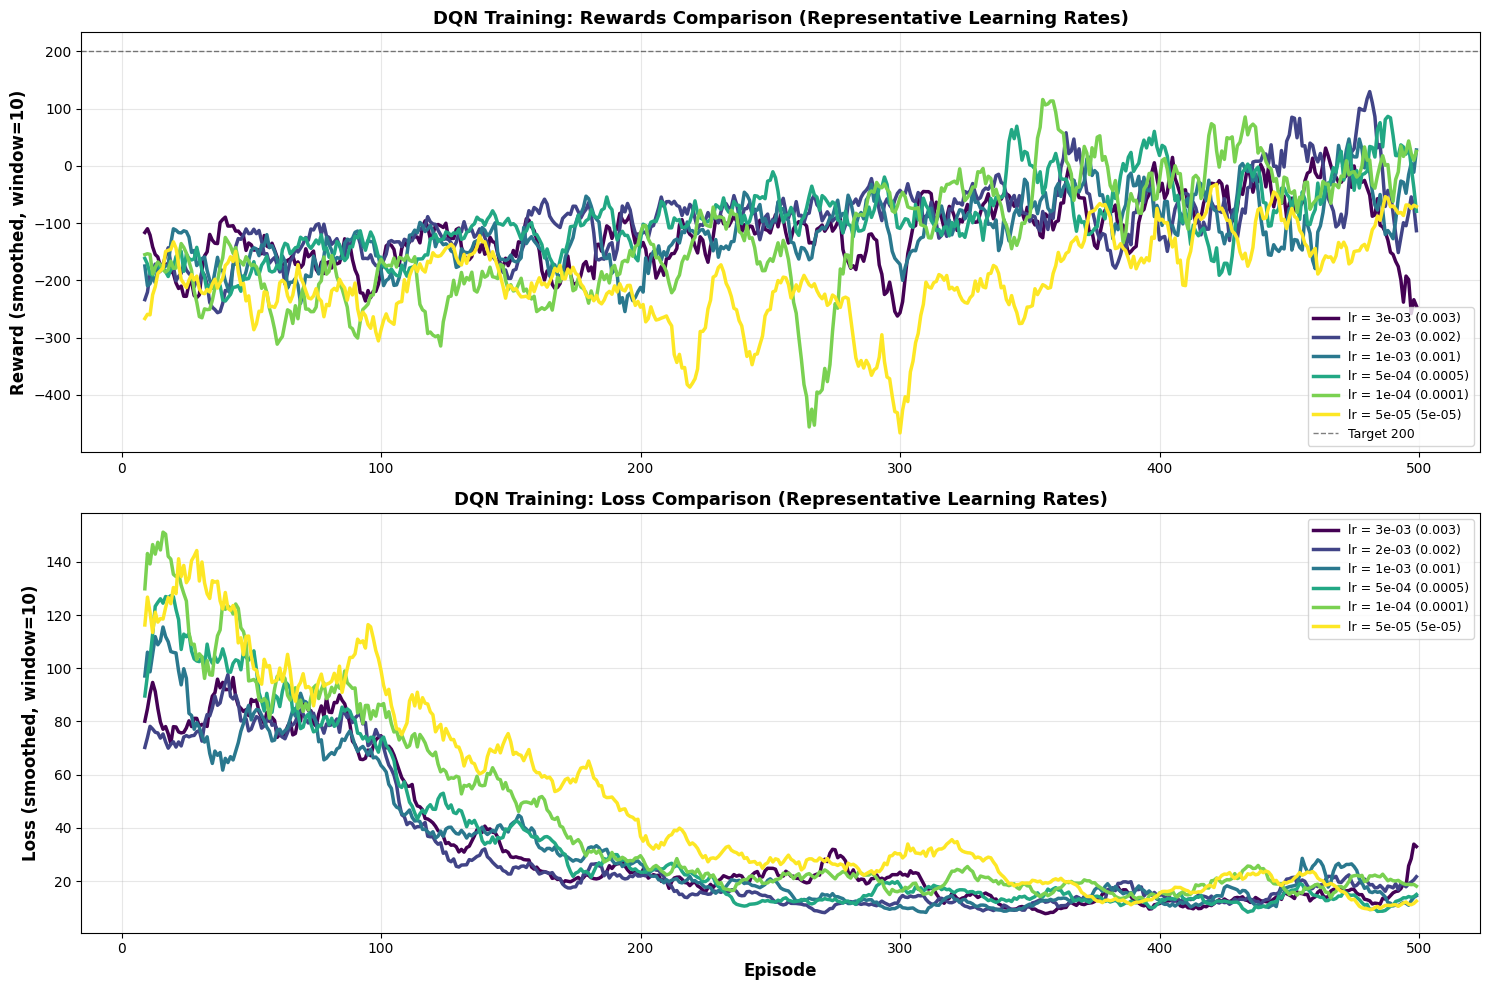

In [8]:
selected_variants = ['3e-03', '2e-03', '1e-03', '5e-04', '1e-04', '5e-05']
selected_variants = [variant for variant in selected_variants if variant in all_results]
colors = plt.cm.viridis(np.linspace(0, 1, len(selected_variants)))
window = 10

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=False)

for idx, variant_name in enumerate(selected_variants):
    result = all_results[variant_name]
    lr = result['learning_rate']
    rewards = result['train_rewards']
    losses = result['losses']
    label = f'lr = {format_lr_label(lr)}'
    color = colors[idx]

    if len(rewards) >= window:
        smoothed_rewards = np.convolve(rewards, np.ones(window) / window, mode='valid')
        reward_episodes = range(window - 1, window - 1 + len(smoothed_rewards))
        ax1.plot(reward_episodes, smoothed_rewards, linewidth=2.5, color=color, label=label)
    else:
        ax1.plot(rewards, linewidth=2.5, color=color, label=label)

    if losses and len(losses) >= window:
        smoothed_losses = np.convolve(losses, np.ones(window) / window, mode='valid')
        loss_episodes = range(window - 1, window - 1 + len(smoothed_losses))
        ax2.plot(loss_episodes, smoothed_losses, linewidth=2.5, color=color, label=label)
    elif losses:
        ax2.plot(losses, linewidth=2.5, color=color, label=label)

ax1.axhline(y=200, color='black', linestyle='--', linewidth=1, alpha=0.5, label='Target 200')
ax1.set_ylabel(f'Reward (smoothed, window={window})', fontsize=12, fontweight='bold')
ax1.set_title('DQN Training: Rewards Comparison (Representative Learning Rates)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=9, loc='lower right')

ax2.set_xlabel('Episode', fontsize=12, fontweight='bold')
ax2.set_ylabel(f'Loss (smoothed, window={window})', fontsize=12, fontweight='bold')
ax2.set_title('DQN Training: Loss Comparison (Representative Learning Rates)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()



## 6. Summary and Analysis

This experiment tested nine learning rates for the vanilla DQN agent while keeping all other baseline settings fixed: 500 training episodes, batch size 32, two hidden layers, hidden dimension 128, epsilon decay 0.995, and gamma 0.99. The tested learning rates were `3e-3 (0.003)`, `2e-3 (0.002)`, `1e-3 (0.001)`, `8e-4 (0.0008)`, `7e-4 (0.0007)`, `5e-4 (0.0005)`, `3e-4 (0.0003)`, `1e-4 (0.0001)`, and `5e-5 (0.00005)`.

### Summary Statistics

The table below compares three complementary indicators: the final training average over the last 25 episodes, the average evaluation reward, and the best single training reward. As with the epsilon-decay and network-depth studies, the most useful interpretation comes from comparing these metrics together rather than selecting the largest number in one column.

| Learning Rate | Final Avg Reward (Last 25) | Evaluation Avg Reward | Best Training Reward |
|---:|---:|---:|---:|
| `1e-3 (0.001)` | `-34.68` | `48.13` | `288.47` |
| `5e-4 (0.0005)` | `8.65` | `13.22` | `300.58` |
| `1e-4 (0.0001)` | `1.44` | `7.50` | `290.04` |
| `3e-4 (0.0003)` | `-21.92` | `0.27` | `264.81` |
| `7e-4 (0.0007)` | `-7.79` | `-33.94` | `276.76` |
| `5e-5 (0.00005)` | `-76.33` | `-82.08` | `247.90` |
| `8e-4 (0.0008)` | `-36.77` | `-107.72` | `275.68` |
| `3e-3 (0.003)` | `-170.79` | `-376.68` | `266.91` |
| `2e-3 (0.002)` | `-49.87` | `-551.88` | `301.00` |

### Interpreting the Training Curves

The individual training curves show that all learning rates remain noisy, which is expected in LunarLander because rewards depend heavily on landing trajectory and crash penalties. However, the curves differ in whether improvement is gradual, whether late-stage performance is retained, and whether good episodes transfer to evaluation.

**Aggressive update behavior (`2e-3 (0.002)` and `3e-3 (0.003)`)**

The two largest learning rates show the clearest instability. `2e-3 (0.002)` achieved the highest single training reward (`301.00`), but it produced the worst evaluation average (`-551.88`). `3e-3 (0.003)` also ended with very poor evaluation performance (`-376.68`) and the lowest final training average (`-170.79`). This suggests that large update steps can occasionally produce a strong trajectory, but they overshoot useful Q-value estimates and fail to produce a reliable final policy.

**Best overall evaluation behavior (`1e-3 (0.001)`)**

`1e-3 (0.001)` is the best overall learning rate in this run because it achieved the highest evaluation average (`48.13`). Its final training average is still negative (`-34.68`), so it is not perfectly stable during training, but evaluation is the more reliable measure of final policy quality because it tests the learned greedy policy after training. Compared with the larger learning rates, `1e-3 (0.001)` avoids severe evaluation collapse while still learning fast enough to produce positive evaluation returns.

**Stable but weaker late-stage behavior (`5e-4 (0.0005)` and `1e-4 (0.0001)`)**

`5e-4 (0.0005)` and `1e-4 (0.0001)` both ended with positive final training averages (`8.65` and `1.44`), suggesting more stable late-stage training than `1e-3 (0.001)`. However, their evaluation averages (`13.22` and `7.50`) were lower than `1e-3 (0.001)`. This indicates that conservative updates can make the final training curve look steadier, but may not refine the greedy policy as effectively within 500 episodes.

**Weak or inconsistent middle-low region (`3e-4 (0.0003)`, `7e-4 (0.0007)`, `8e-4 (0.0008)`, `5e-5 (0.00005)`)**

These settings show mixed or weak results. `3e-4 (0.0003)` is close to neutral in evaluation (`0.27`) but does not clearly outperform the stronger mid-range settings. `7e-4 (0.0007)` and `8e-4 (0.0008)` have reasonable peak training rewards but negative evaluation averages, while `5e-5 (0.00005)` appears too slow and remains negative in both final training and evaluation. This confirms that learning-rate performance is not monotonic: simply making the update smaller does not guarantee better stability or better policy quality.

### Reward-Loss Relationship

The reward and loss comparison shows that loss generally decreases for all representative learning rates, but lower loss alone is not enough evidence of better control. Several settings reduce loss while still producing negative evaluation returns. This is because the loss measures TD-error on replay samples, while evaluation measures whether the learned Q-function actually induces a good landing policy. The best setting should therefore be chosen by combining reward curves, loss behavior, and evaluation results. Under that combined view, `1e-3 (0.001)` gives the best final policy quality, while `5e-4 (0.0005)` is the more conservative alternative with steadier late-stage training.

### Final Performance vs. Evaluation Performance

The mismatch between final training reward and evaluation reward is the central result of this ablation. `5e-4 (0.0005)` and `1e-4 (0.0001)` have positive final training averages, but `1e-3 (0.001)` gives the best evaluation score. Conversely, `2e-3 (0.002)` has the highest best training reward but the worst evaluation score. This means isolated training peaks and even late-stage training averages can be misleading; evaluation performance is the strongest criterion for selecting the overall best learning rate.

### Conclusion

Overall, the learning-rate ablation shows a strong stability trade-off. Very large learning rates (`2e-3` and `3e-3`) make the learned policy brittle, while very small learning rates (`5e-5`) learn too slowly within the 500-episode budget. The best overall setting in this run is `learning_rate = 1e-3 (0.001)`, because it achieved the highest evaluation reward. `5e-4 (0.0005)` remains a useful conservative alternative, but it did not produce the strongest evaluated policy here.

